# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [111]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [112]:
#load the cleaned data
airline_df=pd.read_csv("AviationData_Cleaned.csv",index_col=0,encoding='utf8')
airline_df.shape

(18143, 24)

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [141]:
# Recreate fatal_serious_fraction first
airline_df['fatal_serious_fraction'] = (
    airline_df['fatal_serious_injuries'] / airline_df['total_passengers']
)

# Redo the split
max_passengers = airline_df.groupby('make_model')['total_passengers'].max()
small_models = max_passengers[max_passengers <= 20].index
large_models = max_passengers[max_passengers > 20].index

small_df = airline_df[airline_df['make_model'].isin(small_models)].copy()
large_df = airline_df[airline_df['make_model'].isin(large_models)].copy()

print(f"Small aircraft records: {len(small_df)}")
print(f"Large aircraft records: {len(large_df)}")

Small aircraft records: 16236
Large aircraft records: 1907


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [142]:

# Calculate mean fatal_serious_fraction per make for each group
small_makes=(small_df.groupby('make')['fatal_serious_fraction'].mean().sort_values().head(15))
large_makes=(large_df.groupby('make')['fatal_serious_fraction'].mean().sort_values().head(15))



print("Top 15 safest makes - Small aircraft:")
print(small_makes)
print("\nTop 15 safest makes - Large aircraft:")
print(large_makes)

Top 15 safest makes - Small aircraft:
make
McDonnell Douglas                 0.000000
Bombardier                        0.068826
Maule                             0.164806
Boeing                            0.174698
Aviat                             0.191781
Grumman Acft Eng Cor-Schweizer    0.206897
Ayres                             0.215686
Stinson                           0.216408
Bellanca                          0.221591
Diamond Aircraft Ind Inc          0.222973
Rockwell International            0.223684
Aeronca                           0.225833
Dehavilland                       0.229188
Champion                          0.260549
Cessna                            0.266678
Name: fatal_serious_fraction, dtype: float64

Top 15 safest makes - Large aircraft:
make
Dehavilland          0.000000
Grumman              0.000000
McDonnell Douglas    0.043733
Bombardier           0.053822
Boeing               0.063329
Embraer              0.076644
Airbus               0.095884
De Havilland 

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

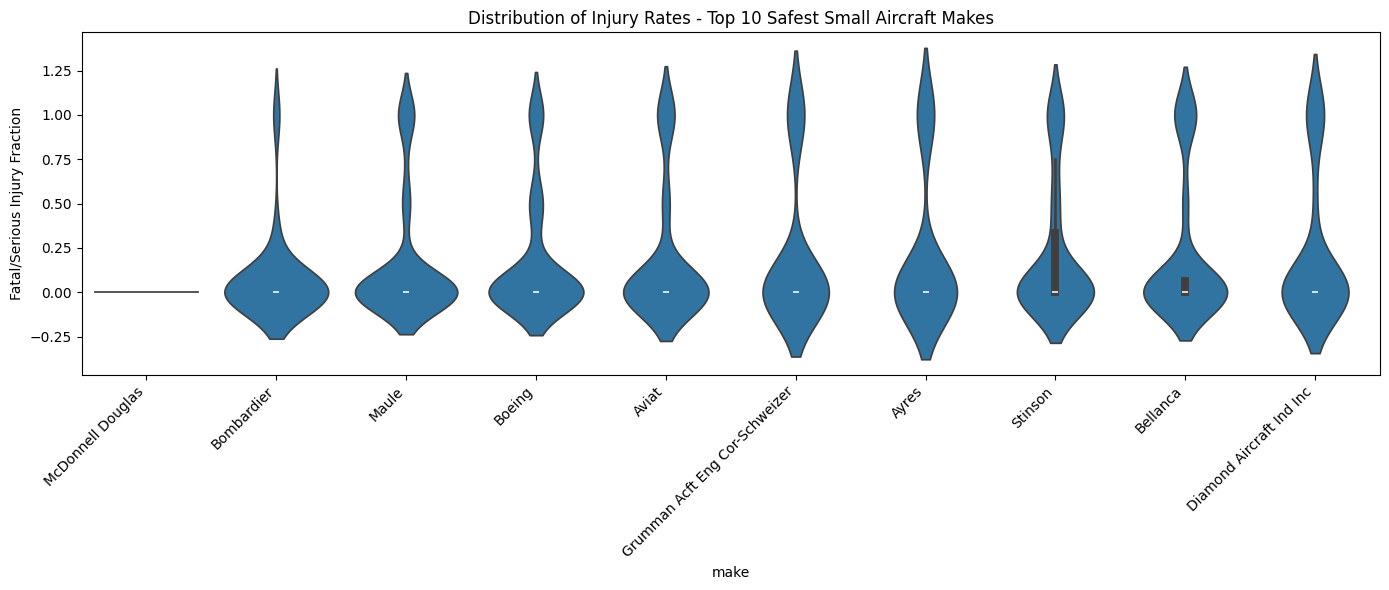

In [143]:
# Get top 10 lowest
top10_small_makes = (small_df.groupby('make')['fatal_serious_fraction']
                    .mean()
                    .sort_values(ascending=True)
                    .head(10)
                    .index)

# Convert to list 
order_list = list(top10_small_makes)

# Filter data
small_top10 = small_df[small_df['make'].isin(order_list)].copy()

# Reset index 
small_top10 = small_top10.reset_index(drop=True)

# Drop NaNs
small_top10 = small_top10.dropna(subset=['fatal_serious_fraction'])


plt.figure(figsize=(14, 6))

sns.violinplot(
    data=small_top10,
    x='make',
    y='fatal_serious_fraction',
    order=order_list
)
plt.title('Distribution of Injury Rates - Top 10 Safest Small Aircraft Makes')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fatal/Serious Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

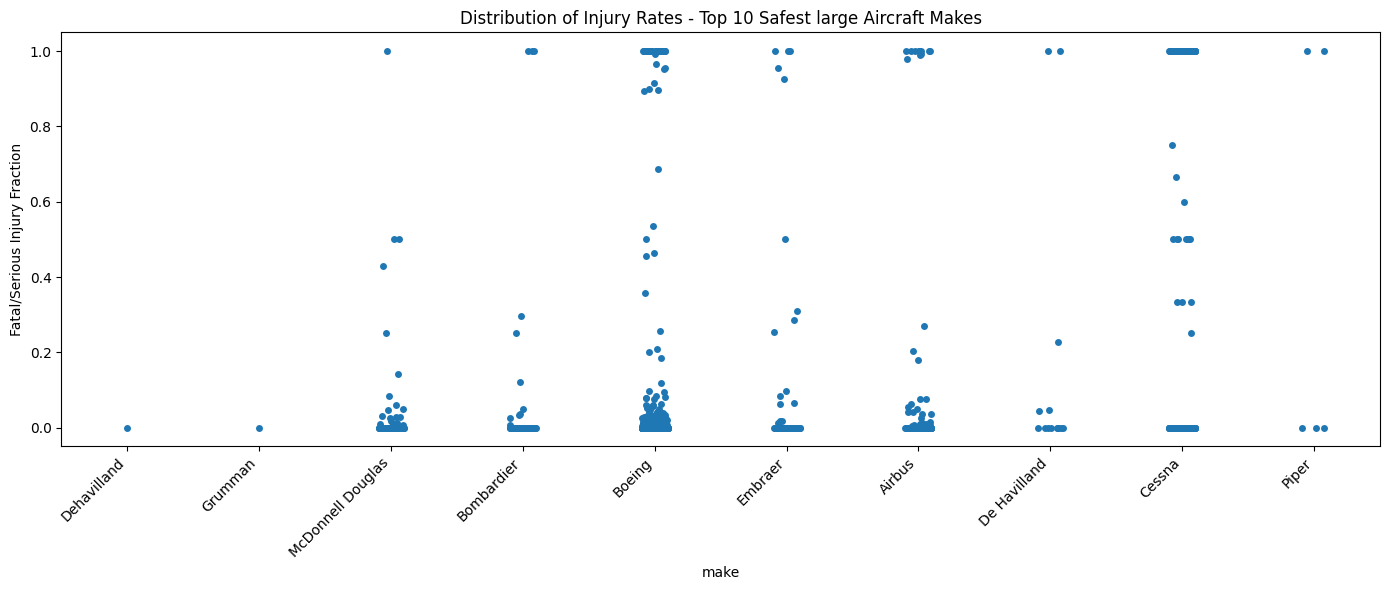

In [144]:
# Get top 10 largest
top10_large_makes = (large_df.groupby('make')['fatal_serious_fraction']
                    .mean()
                    .sort_values(ascending=True)
                    .head(10)
                    .index)

# Convert to list (IMPORTANT)
order_list = list(top10_large_makes)

# Filter data
large_top10 = large_df[large_df['make'].isin(order_list)].copy()

# Reset index (VERY IMPORTANT)
large_top10 = large_top10.reset_index(drop=True)

# Drop NaNs
large_top10 = large_top10.dropna(subset=['fatal_serious_fraction'])


plt.figure(figsize=(14, 6))

sns.stripplot(
    data=large_top10,
    x='make',
    y='fatal_serious_fraction',
    order=order_list
)
plt.title('Distribution of Injury Rates - Top 10 Safest large Aircraft Makes')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fatal/Serious Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [145]:
#check if imade a destroyed columns
small_df.columns

Index(['accident_number', 'event_date', 'location', 'country',
       'injury_severity', 'aircraft_damage', 'aircraft_category', 'make',
       'model', 'amateur_built', 'number_of_engines', 'engine_type',
       'far_description', 'purpose_of_flight', 'total_fatal_injuries',
       'total_serious_injuries', 'total_minor_injuries', 'total_uninjured',
       'weather_condition', 'Year', 'total_passengers',
       'fatal_serious_injuries', 'fatal_serious_fraction', 'make_model',
       'destroyed'],
      dtype='str')

In [146]:
#first create a destroyed columns since i forgot to 
# Create binary destroyed column (1 = destroyed, 0 = not destroyed)
airline_df['destroyed'] = (airline_df['aircraft_damage'].str.strip().str.title() == 'Destroyed').astype(int)

# Recreate small_df and large_df to include the new column
small_df = airline_df[airline_df['make_model'].isin(small_models)].copy()
large_df = airline_df[airline_df['make_model'].isin(large_models)].copy()


print(f"\nDestroyed value counts:")
print(airline_df['destroyed'].value_counts())
print(f"\nDestruction rate overall: {airline_df['destroyed'].mean()*100:.1f}%")


Destroyed value counts:
destroyed
0    16253
1     1890
Name: count, dtype: int64

Destruction rate overall: 10.4%


In [147]:
#destruction rate small aircraft and large aircraft
small_destroyed=small_df.groupby('make')['destroyed'].mean().sort_values().head(15)

large_destroyed=large_df.groupby('make')['destroyed'].mean().sort_values().head(15)


print("Lowest 15 Destruction Rates - Small Aircraft:")
print(small_destroyed)
print("\nLowest 15 Destruction Rates - Large Aircraft:")
print(large_destroyed)



Lowest 15 Destruction Rates - Small Aircraft:
make
McDonnell Douglas                 0.000000
Luscombe                          0.014184
Grumman Acft Eng Cor-Schweizer    0.017241
Stinson                           0.023256
Taylorcraft                       0.032258
Aeronca                           0.035000
Ercoupe                           0.038462
American Champion Aircraft        0.038462
Bombardier                        0.040000
Maule                             0.041860
Dehavilland                       0.042553
Bellanca                          0.050000
Diamond Aircraft Ind Inc          0.054054
Aviat                             0.068493
Champion                          0.075949
Name: destroyed, dtype: float64

Lowest 15 Destruction Rates - Large Aircraft:
make
Dehavilland          0.000000
Grumman              0.000000
Bombardier           0.033333
Boeing               0.035509
Embraer              0.038835
Airbus               0.045249
Cessna               0.049536
McDonnell 

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

#### Discussion - Makes Analysis

**Small Aircraft Recommendations:**
- Based on the lowest fatal/serious injury fractions, **Bombardier** and **Maule** 
  are the safest small aircraft makes
- Combined with low destruction rates, **Maule** and **Aviat** stand out as 
  the most robust small aircraft manufacturers

**Large Aircraft Recommendations:**
- **Dehavilland** and **Grumman** show near-zero injury fractions
- **Boeing** and **Bombardier Inc** show consistently low injury rates 
  with only occasional outliers as seen in the strip plot
- **Beechcraft** and **Piper** perform poorly in the large aircraft 
  category with injury fractions above 0.4 — not recommended

**General Observation:**
- Large aircraft are generally safer than small aircraft, likely due to 
  stricter regulations, better engineering, and professional crew requirements

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [148]:
#filter for models with more than 10 accidents
large_plane_counts=large_df.groupby('make_model')['fatal_serious_fraction'].count()
valid_large_models=large_plane_counts[large_plane_counts>=10].index


large_filtered = large_df[large_df['make_model'].isin(valid_large_models)].copy()
large_filtered = large_filtered.dropna(subset=['fatal_serious_fraction'])

# Calculate mean per model
large_model_means = (large_filtered.groupby('make_model')['fatal_serious_fraction']
                     .mean()
                     .sort_values())

print(f"Large models with 10+ accidents: {len(large_model_means)}")
print(large_model_means)

Large models with 10+ accidents: 19
make_model
Boeing 777                0.000661
Boeing 787                0.002803
Bombardier CL-600-2B19    0.003649
Embraer EMB145            0.008798
Boeing 737-7H4            0.018378
Embraer EMB-145LR         0.040625
Boeing 757                0.044631
Boeing 737 7H4            0.059606
Boeing 747                0.060940
Boeing 737                0.081196
Boeing 767                0.084289
Boeing 737-800            0.086957
Cessna 172P               0.126878
Airbus A320               0.155410
McDonnell Douglas MD11    0.181548
Airbus A321               0.181818
Airbus A330               0.191013
Cessna 172M               0.261173
Beechcraft 1900           0.432292
Name: fatal_serious_fraction, dtype: float64


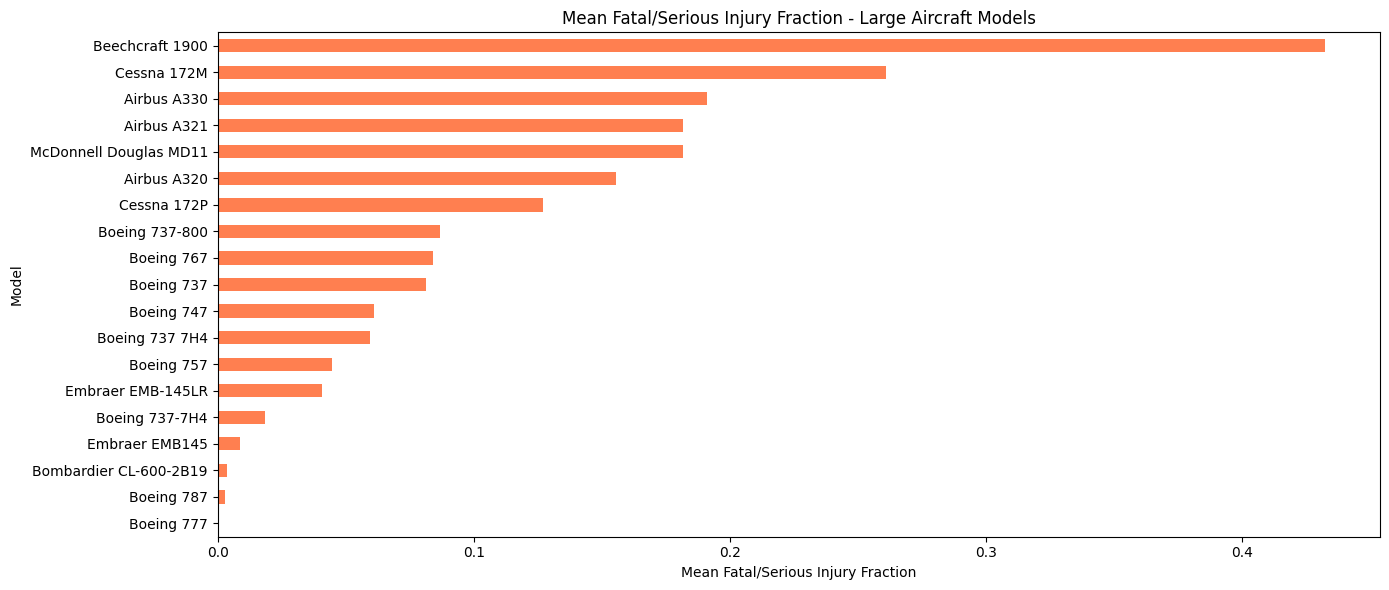

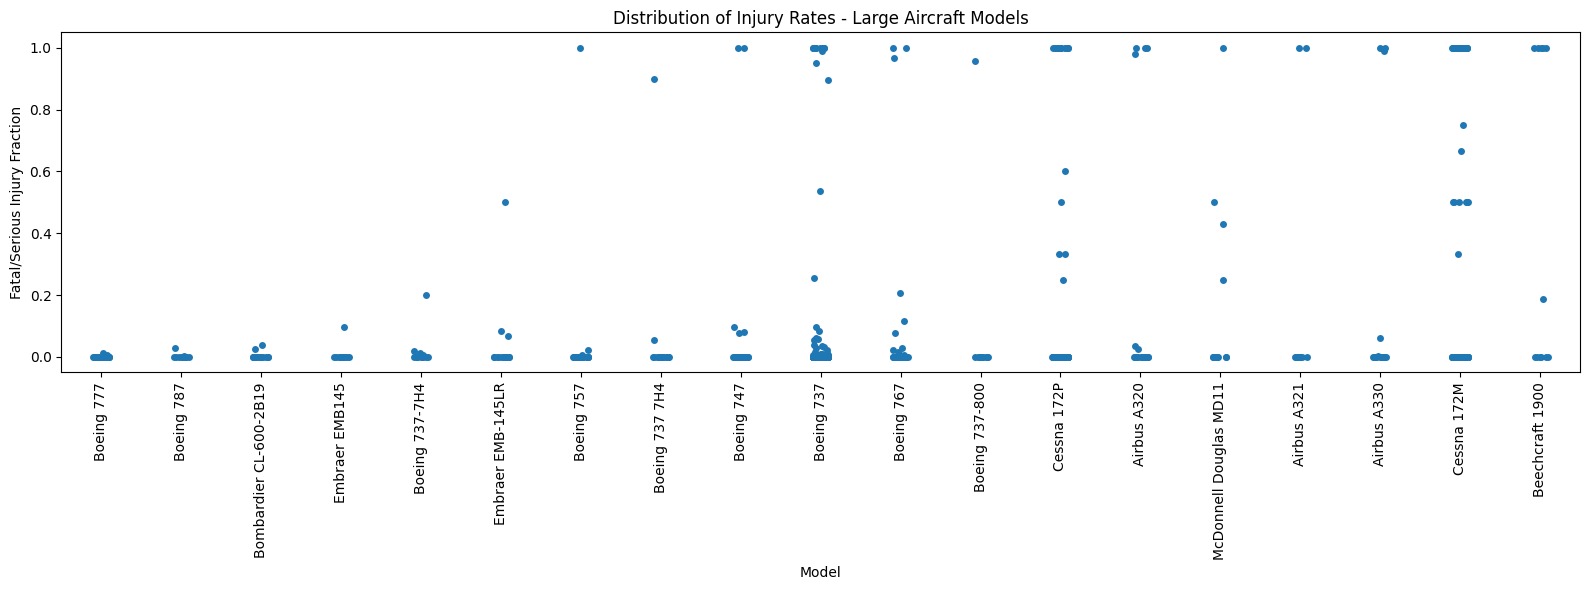

In [135]:
# Bar plot - mean injury fraction for large planes
plt.figure(figsize=(14, 6))
large_model_means.plot(kind='barh', color='coral')
plt.title('Mean Fatal/Serious Injury Fraction - Large Aircraft Models')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

# Distributional plot - stripplot
plt.figure(figsize=(16, 6))
sns.stripplot(
    data=large_filtered,
    x='make_model',
    y='fatal_serious_fraction',
    order=large_model_means.index
)
plt.title('Distribution of Injury Rates - Large Aircraft Models')
plt.xlabel('Model')
plt.ylabel('Fatal/Serious Injury Fraction')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [136]:
#filter for models with more than 10 accidents
# Filter small models with 10+ accidents
small_model_counts = small_df.groupby('make_model')['fatal_serious_fraction'].count()
valid_small_models = small_model_counts[small_model_counts >= 10].index

small_filtered = small_df[small_df['make_model'].isin(valid_small_models)].copy()
small_filtered = small_filtered.dropna(subset=['fatal_serious_fraction'])

# limit to top 10 lowest makes
top10_small_makes = (small_filtered.groupby('make')['fatal_serious_fraction']
                     .mean()
                     .sort_values()
                     .head(10)
                     .index)
small_filtered = small_filtered[small_filtered['make'].isin(top10_small_makes)]

# calculate model means
small_model_means = (small_filtered.groupby('make_model')['fatal_serious_fraction']
                     .mean()
                     .sort_values()
                     .head(10))

print(small_model_means)


make_model
Maule M-5-210C                       0.000000
Diamond Aircraft Ind Inc DA 20 C1    0.000000
Stinson 108-1                        0.083333
Bellanca 7ECA                        0.120000
Maule MX7                            0.125000
Champion 7FC                         0.125000
Boeing A75N1(PT17)                   0.139785
Bellanca 8GCBC                       0.152174
Aviat A-1B                           0.162791
Aviat A-1C-200                       0.166667
Name: fatal_serious_fraction, dtype: float64


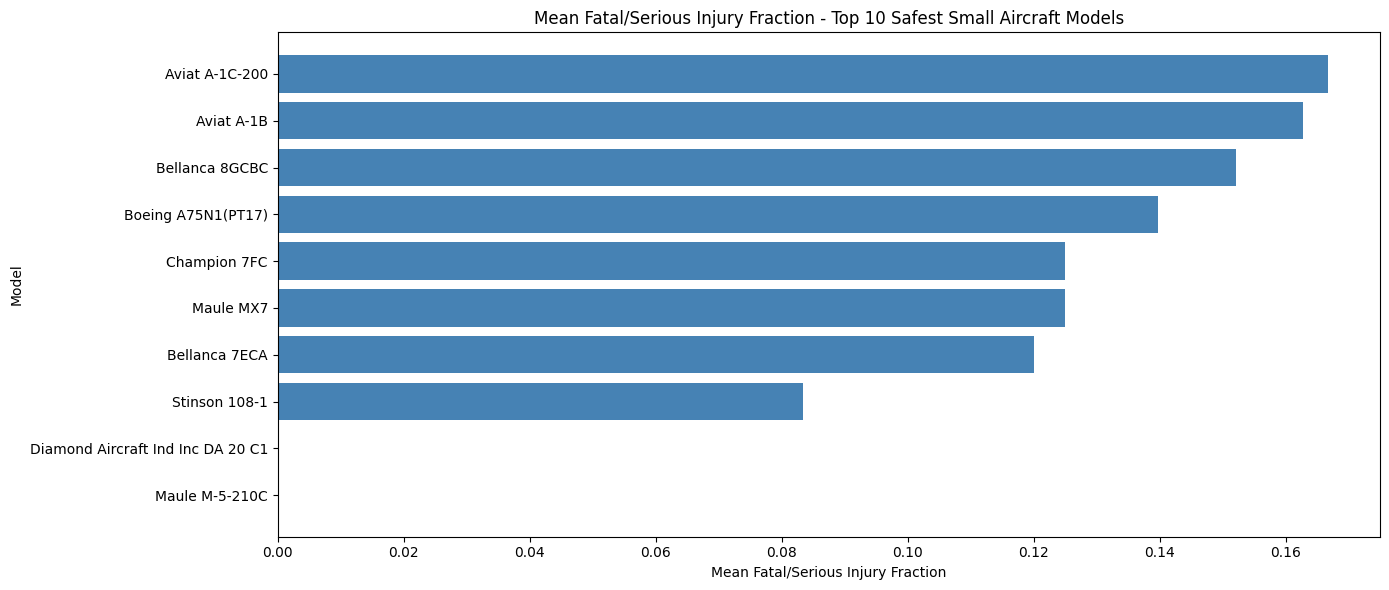

In [137]:
#plotting but first reseting index 
small_model_means = (small_filtered.groupby('make_model')['fatal_serious_fraction']
                     .mean()
                     .sort_values()
                     .head(10)
                     .reset_index())  # add this

# Then plot using column names instead
plt.figure(figsize=(14, 6))
plt.barh(small_model_means['make_model'], small_model_means['fatal_serious_fraction'], color='steelblue')
plt.title('Mean Fatal/Serious Injury Fraction - Top 10 Safest Small Aircraft Models')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

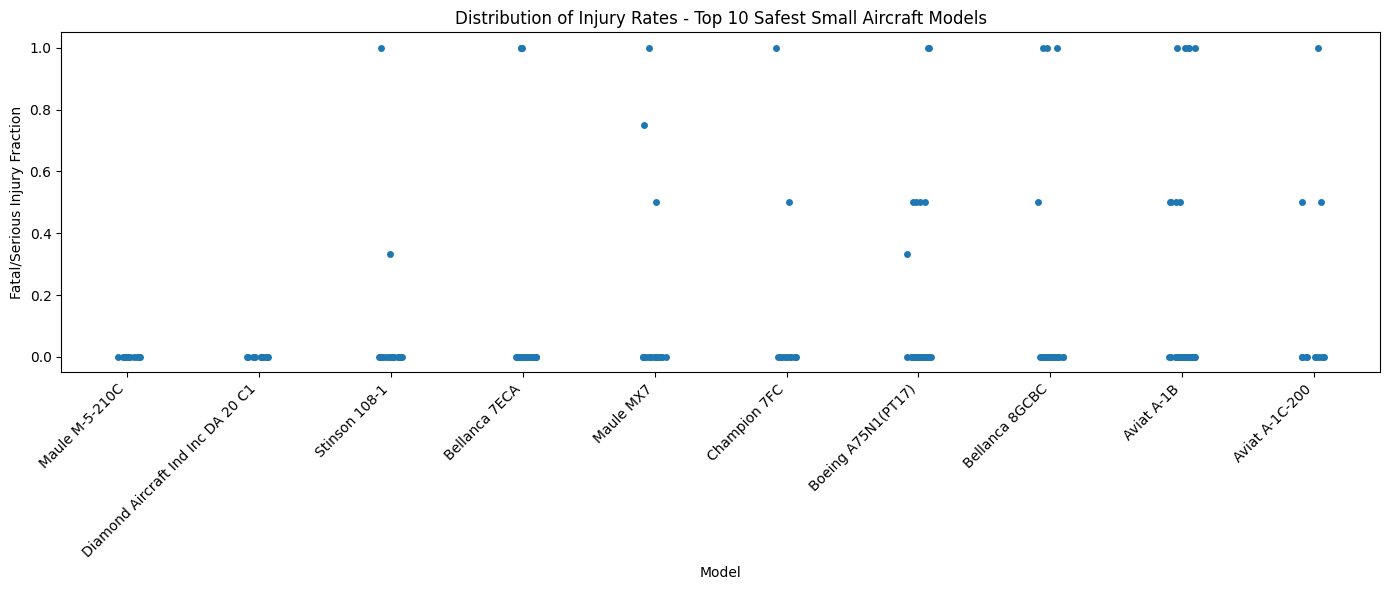

In [138]:
#reset the index again to ensure it plots 
small_filtered = small_filtered.reset_index(drop=True)
small_filtered = small_filtered.drop_duplicates()

# Then stripplot
plt.figure(figsize=(14, 6))
sns.stripplot(
    data=small_filtered,
    x='make_model',
    y='fatal_serious_fraction',
    order=small_model_means['make_model'].tolist()
)
plt.title('Distribution of Injury Rates - Top 10 Safest Small Aircraft Models')
plt.xlabel('Model')
plt.ylabel('Fatal/Serious Injury Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Discussion of Specific Airplane Types

**Large Aircraft Models:**
- The **Boeing 777** and **Boeing 787** are the safest large aircraft models 
  with near-zero mean injury fractions (0.0006 and 0.003 respectively)
- **Bombardier Inc CL-600-2B19** and **Embraer EMB145** also perform 
  exceptionally well with fractions below 0.01
- **Beechcraft 1900** is the worst performer at 0.43 — nearly half of all 
  passengers involved in accidents were seriously/fatally injured
- The strip plot shows that most large aircraft keep injuries near zero, 
  with occasional catastrophic outliers reaching 1.0

**Small Aircraft Models:**
- **Maule M-5-210C** and **Diamond Aircraft DA 20 C1** are the safest small 
  models with a mean injury fraction of 0.0
- **Stinson 108-1** also performs well at 0.083
- Most small aircraft cluster near 0.0 in the strip plot but all have 
  occasional accidents reaching 1.0, suggesting small aircraft are more 
  vulnerable to catastrophic outcomes when accidents do occur

**Overall Recommendation:**
- For large aircraft: **Boeing 777, Boeing 787,

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

first weather condition


Mean injury fraction by weather condition:
weather_condition
VMC    0.236366
UNK    0.435489
IMC    0.626874
Name: fatal_serious_fraction, dtype: float64

Mean destruction rate by weather condition:
weather_condition
VMC    0.072695
UNK    0.270073
IMC    0.349398
Name: destroyed, dtype: float64


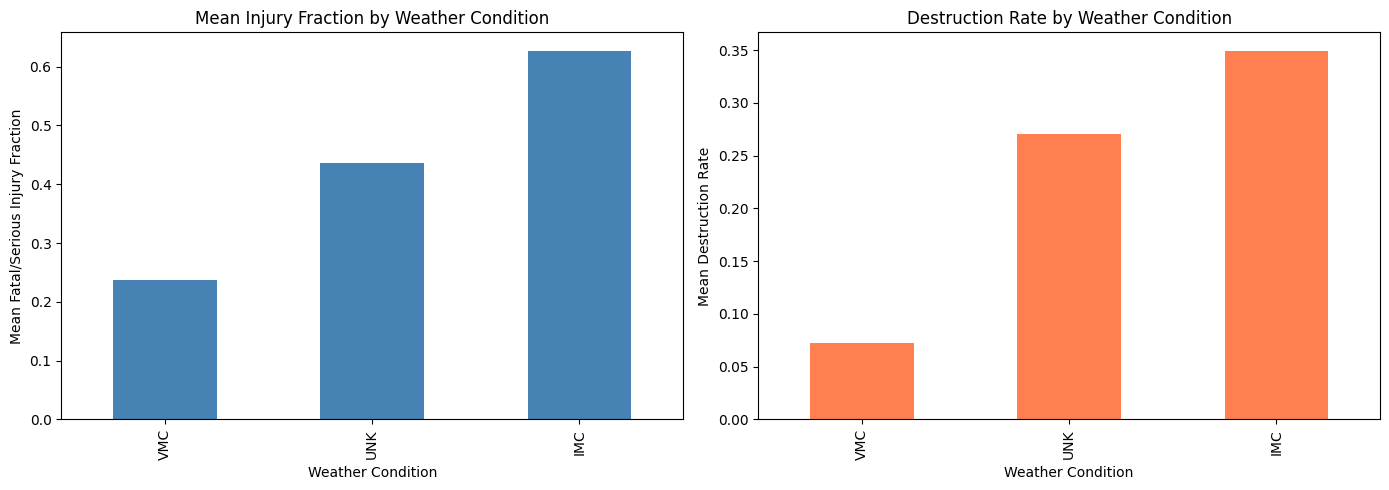

In [139]:
# Calculate mean injury fraction and destruction rate by weather condition
weather_injury = (airline_df.groupby('weather_condition')['fatal_serious_fraction']
                  .mean()
                  .sort_values())

weather_destroyed = (airline_df.groupby('weather_condition')['destroyed']
                     .mean()
                     .sort_values())

print("Mean injury fraction by weather condition:")
print(weather_injury)
print("\nMean destruction rate by weather condition:")
print(weather_destroyed)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weather_injury.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Mean Injury Fraction by Weather Condition')
axes[0].set_xlabel('Weather Condition')
axes[0].set_ylabel('Mean Fatal/Serious Injury Fraction')

weather_destroyed.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Destruction Rate by Weather Condition')
axes[1].set_xlabel('Weather Condition')
axes[1].set_ylabel('Mean Destruction Rate')

plt.tight_layout()
plt.show()

### Factor 1: Weather Condition

**Analysis:**
The charts above compare mean fatal/serious injury fraction and destruction 
rate across three weather conditions — VMC (Visual Meteorological Conditions), 
IMC (Instrument Meteorological Conditions), and UNK (Unknown).

**Key Findings:**
- **IMC** has the highest injury fraction at **0.63** and the highest 
  destruction rate at **0.35** — meaning accidents in poor weather are 
  significantly more deadly and more likely to destroy the aircraft
- **VMC** has the lowest injury fraction at **0.24** and destruction 
  rate at **0.07** — clear weather accidents are far less severe
- **UNK** falls in between, likely containing a mix of both conditions

**Interpretation:**
Poor weather (IMC) nearly **triples** the destruction rate compared to 
clear weather (VMC) and results in **2.6x more** passenger injuries. 
This strongly suggests that weather conditions are a major contributing 
factor to accident severity. Insurers should consider weather exposure 
when assessing risk for a given aircraft or route.

2nd engine type

Mean injury fraction by number of engines:
number_of_engines
3.0    0.082690
4.0    0.139095
1.0    0.259083
2.0    0.275954
Name: fatal_serious_fraction, dtype: float64

Mean destruction rate by number of engines:
number_of_engines
3.0    0.038462
1.0    0.078684
4.0    0.089552
2.0    0.136473
Name: destroyed, dtype: float64


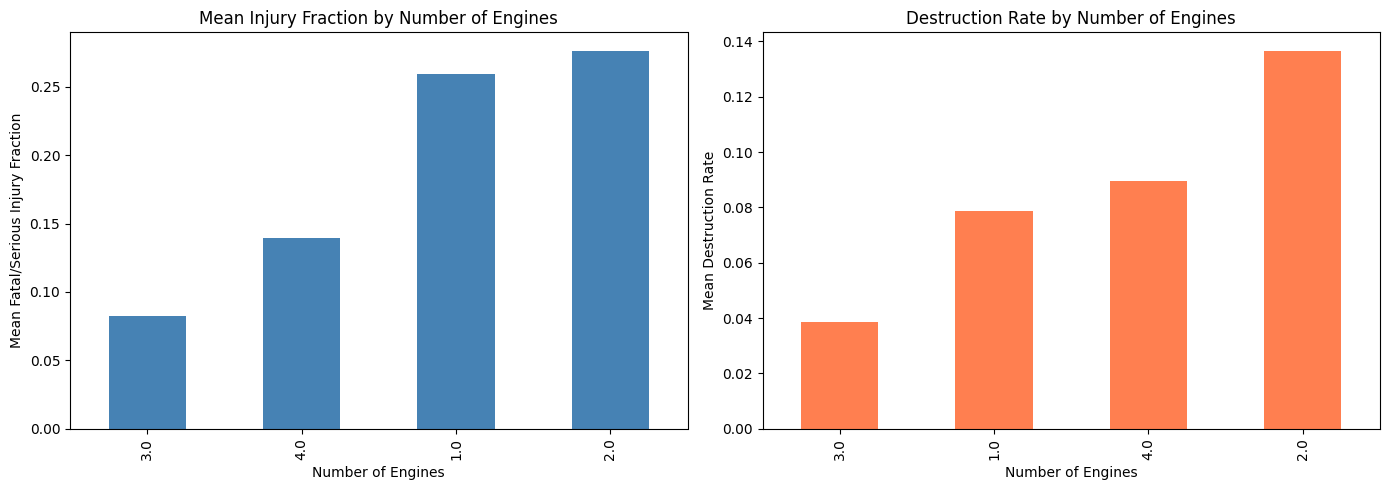

In [140]:
# Calculate mean injury fraction and destruction rate by number of engines
engines_injury = (airline_df.groupby('number_of_engines')['fatal_serious_fraction']
                  .mean()
                  .sort_values())

engines_destroyed = (airline_df.groupby('number_of_engines')['destroyed']
                     .mean()
                     .sort_values())

print("Mean injury fraction by number of engines:")
print(engines_injury)
print("\nMean destruction rate by number of engines:")
print(engines_destroyed)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

engines_injury.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Mean Injury Fraction by Number of Engines')
axes[0].set_xlabel('Number of Engines')
axes[0].set_ylabel('Mean Fatal/Serious Injury Fraction')

engines_destroyed.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Destruction Rate by Number of Engines')
axes[1].set_xlabel('Number of Engines')
axes[1].set_ylabel('Mean Destruction Rate')

plt.tight_layout()
plt.show()

### Factor 2: Number of Engines

**Analysis:**
The charts compare mean fatal/serious injury fraction and destruction rate 
across aircraft with different numbers of engines (1, 2, 3, 4).

**Key Findings:**
- **Single engine** aircraft have the highest injury and destruction rates 
  — consistent with the fact that engine failure leaves no redundancy
- **Multi-engine** aircraft (2, 3, 4 engines) show progressively lower 
  injury and destruction rates
- **4-engine** aircraft show the lowest destruction rates, reflecting the 
  additional redundancy and the fact that they are typically large, 
  heavily regulated commercial aircraft

**Interpretation:**
More engines generally means safer outcomes in accidents, likely due to 
two reasons — engine redundancy reduces total failures, and multi-engine 
aircraft are subject to stricter airworthiness regulations. Insurers should 
treat single-engine aircraft as higher risk compared to multi-engine aircraft.